# Regression (회귀)
1. 회귀 문제가 뭔지 이해
2. X와 y 구조 확인
3. LinearRegression 으로 학습
4. 예측값과 실제값 비교
5. 회귀 평가 지표 이해

- 분류: 꽃 품종, 스팸/정상, 위험도 낮음/중간/높음
- 회귀: 점수, 가격, 온도, 개체 수, 위험도 점수

---

# 1. 간단한 점수 예측 예제

In [20]:
import numpy as np
from sklearn.linear_model import LinearRegression

# X: 공부 시간
X = np.array(
    [[1], 
     [2], 
     [3], 
     [4], 
     [5]]
)

# y: 시험 점수
y = np.array([50, 60, 70, 80, 90])

model = LinearRegression()
model.fit(X, y)

pred = model.predict([[6]])

print("6시간 공부했을 때 예측 점수:", pred)

6시간 공부했을 때 예측 점수: [100.]


#### 모델은 다음 관계를 학습한다.
- 공부 시간이 늘어나면 점수가 증가한다.
---

# 2. Linear Regression이 학습하는 것
- 선형 회귀는 데이터를 가장 잘 설명하는 직선을 찾는다.

```
y = wx + b
```

```
여기서
w = 기울기, weight, coefficient
b = 절편, bias, intercept
```

In [21]:
print("기울기 w:", model.coef_)
print("절편 b:", model.intercept_)

기울기 w: [10.]
절편 b: 40.00000000000001


- 위의 출력을 보면, 아래의 식을 배운 것이다.
```text
점수 = 10*공부시간 + 40
```

그래서 공부 시간이 6시간이면
```text
점수 = 10*6 + 40 = 100
```
---

# 3. Diabetes 데이터셋으로 회귀 실습

scikit-learn에 들어 있는 당뇨병 데이터 활용.

이 데이터셋은, 입력 특성들을 보고 질병 진행 정도라는 숫자값을 예측하는 회귀 문제다.

In [22]:
# 데이터 구조 확인 코드
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("X shape:", X.shape)
print("y shape:", y.shape)

print("특성 이름:", diabetes.feature_names)
print()

print("X 앞 3개:")
print(X[:3])
print()

print("y 앞 10개:")
print(y[:10])

X shape: (442, 10)
y shape: (442,)
특성 이름: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

X 앞 3개:
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]]

y 앞 10개:
[151.  75. 141. 206. 135.  97. 138.  63. 110. 310.]


위의 출력에서 중요한 것은 

- X shape: (442, 10)
- y shape: (442,)

의미는
```text
    데이터 개수 = 442개
    입력 특성 개수 = 10개
    정답값 개수 = 442개
```

즉
```text
    X = 환자별 측정 특성 10개
    y = 질병 진행 정도 숫자값
```
---

# 4. Train/Test 분리
분류 때와 똑같이 학습용과 테스트용으로 나눈다.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 전체 442개 중 80%는 학습, 20%는 테스트에 사용
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (353, 10)
X_test shape: (89, 10)
y_train shape (353,)
y_test shape: (89,)


---
# 5. Linear Regression 학습

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("예측값 앞 10개:")
print(pred[:10])
print()

print("실제값 앞 10개:")
print(y_test[:10])

예측값 앞 10개:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]

실제값 앞 10개:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]


여기서 중요한 점은 분류와 다르다는 것이다.

분류에서는 예측값이 아래와 같았다.
```text
    [0, 1, 2, 1, 0]
```
즉, 클래스 번호였다.



하지만 회귀에서는 예측값이 이런 식이다
```text
    [139.5475584  179.51720835 134.03875572, ...]
```
즉, 연속적인 숫자값이다.

---
# 6. 회귀 모델 평가

분류에서는 accuracy 사용 (어디 클래스에 속하는지)

반대로, 회귀에서는 정확도라는 개념을 그대로 쓰긴 어렵다.
- 예측값이 숫자이기 때문에 얼마나 틀렸는지, 즉 오차를 봐야함

대표 지표는 다음과 같다.
```text
    MAE = 평균 절대 오차
    MSE = 평균 제곱 오차
    RMSE = 평균 제곱근 오차
    R^2 = 설명력 점수
```

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 42.794094679599944
MSE: 2900.193628493482
RMSE: 53.85344583676593
R2 Score: 0.4526027629719195


---

# 7. 평가 지표 해석

### MAE
```text
    Mean Absolute Error
    평균적으로 실제값과 예측값이 얼마나 차이나는가
```

예를 들어 MAE가 40이면
```text
    평균적으로 약 40정도 틀린다
```

---

### MSE
```text
    Mean Squared Error
    오차를 제곱해서 평균낸 값
```
큰 오차에 더 큰 벌점을 준다

---

### RMSE
```text
    Root Mean Squared Error
    MSE에 루트를 씌운 값
```
MAE보다 큰 오차에 민감하면서도 원래 단위와 비슷하게 해석할 수 있다.

---

## R2 Score => 중요
```text
    모델이 데이터를 얼마나 잘 설명하는지 나타내는 함수
```

대략적으로
```text
    1에 가까울수록 좋음
    0 근처면, 평균값 예측과 비슷함
    음수가 나오면 평균값 예측보다도 못함
```
위의 결과에서는 R2 Score 가 45.3% 정도 나왔는데, 이는
- 모델이 전체 데이터 변동성의 약 45.3% 정도를 설명한다
- 즉, 이 Linear Regression 모델은 데이터의 패턴을 어느 정도는 잡았지만, 절반 이상은 아직 설명하지 못하고 있다

---

# 8. 실제값과 예측값 비교하기

In [26]:
import pandas as pd

result = pd.DataFrame({
    "실제값": y_test,
    "예측값": pred,
    "오차": y_test - pred
})

result.head(10)

,실제값,예측값,오차
0,219.0,139.547558,79.452442
1,70.0,179.517208,-109.517208
2,202.0,134.038756,67.961244
3,230.0,291.417029,-61.417029
4,111.0,123.789659,-12.789659
5,84.0,92.172347,-8.172347
6,242.0,258.232389,-16.232389
7,272.0,181.337321,90.662679
8,94.0,90.224113,3.775887
9,96.0,108.633759,-12.633759


결과를 보면 일부는 잘 맞고 일부는 오차가 매우 크다

따라서 다음과 같은 결론을 내릴 수 있다.
```text
    Linear Regression 이라는 단순한 모델로는
    diabetes 데이터의 복잡한 관계를 완벽히 설명하기 어렵다
```
라고 보면 된다.

---

# 9. 그래프로 확인하기

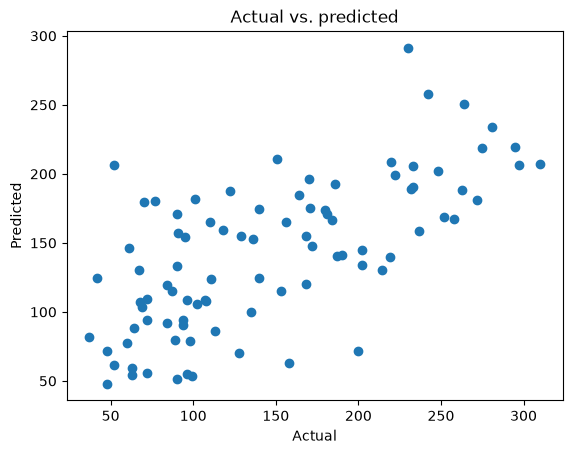

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs. predicted")
plt.show()

### 위의 그래프에서 점들이 대각선 근처에 모일수록 좋은 모델이다.

- 실제값과 예측값이 비슷함  
    - 좋은 모델
    
- 점들이 많이 흩어짐
    - 오차가 큼

---

# 10. 정리

### 분류는 클래스를 예측한다.
### 회귀는 숫자값을 예측한다.

분류 예측값:
- 0, 1, 2
- 스팸, 정상
- 낮음, 중간, 높음

회귀 예측값:
- 87.3
- 152.8
- 0.74
- 24.5

### 회귀 모델 평가는 정확도가 아니라 오차를 본다
- MAE  -> 평균적으로 얼마나 틀렸는가
- MSE  -> 큰 오차를 더 강하게 반영
- RMSE -> MSE를 원래 단위에 가깝게 변환
- R^2  -> 모델 설명력